In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

paths = load_paths()
logger = setup_logger(level="INFO")

# Load Data and Predictions
logger.info("Loading data and predictions...")
# We load the ensemble predictions as they represent the final system
df_preds = pd.read_parquet(paths.artifacts_dir / "ensemble" / "preds.parquet")

# Load Feature Pipeline to get feature names
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline = FeaturePipeline.load(feature_art)
feature_cols = pipeline.model_feature_names()

# Load the raw features to analyze correlations
# We need to reconstruct the full dataframe with features + preds
# This assumes features.parquet exists for both datasets
vnat_feats = pd.read_parquet(paths.data_processed / "vnat" / "features.parquet")
vnat_feats["dataset"] = "vnat" # Add dataset column

iscx_feats = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet")
iscx_feats["dataset"] = "iscx" # Add dataset column

df_features = pd.concat([vnat_feats, iscx_feats], ignore_index=True)

# Merge predictions with features
# We merge on flow_id. Note: df_preds might be a subset if filtering was applied during training
df_full = pd.merge(df_preds, df_features[feature_cols + ["flow_id", "dataset"]], on="flow_id", how="left")

print(f"Full Analysis DataFrame Shape: {df_full.shape}")


2026-02-27 22:31:57 | INFO | ai-vpn-firewall | Loading data and predictions...
Full Analysis DataFrame Shape: (12989, 66)


2026-02-27 22:31:57 | INFO | ai-vpn-firewall | Analyzing Feature Importance...


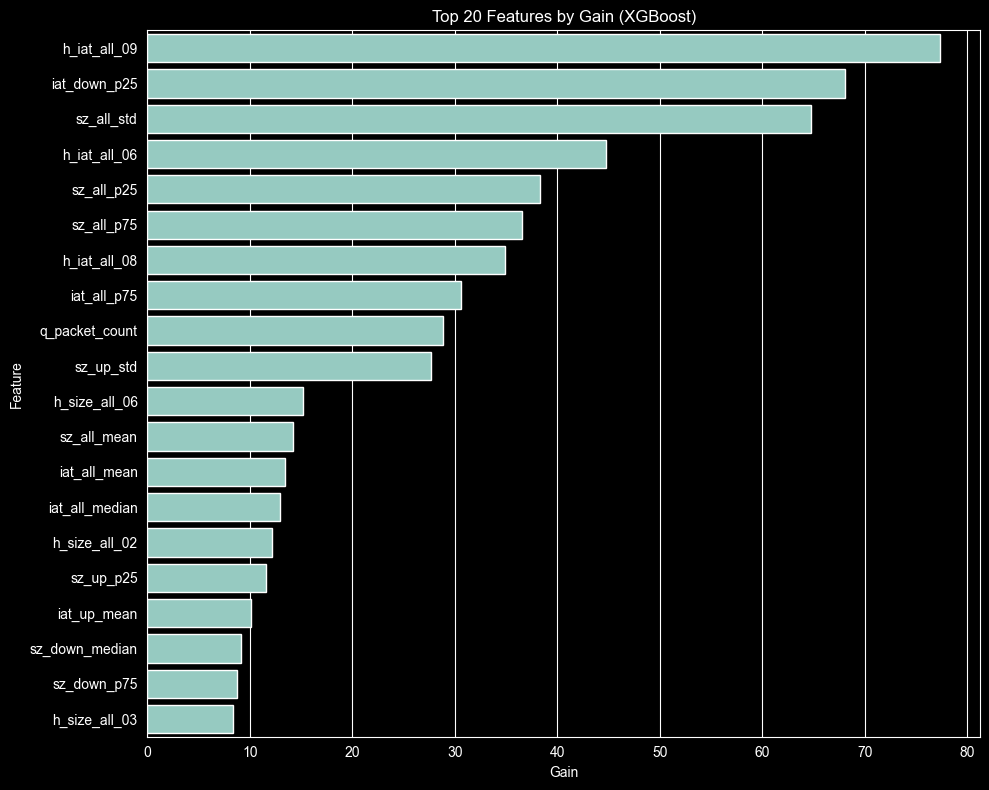

Top 5 Features:
         Feature       Gain
49  h_iat_all_09  77.391159
30  iat_down_p25  68.078163
4     sz_all_std  64.777824
46  h_iat_all_06  44.751526
5     sz_all_p25  38.330276

Top feature 'h_iat_all_09' accounts for 11.08% of total gain.


In [2]:
# 1. Feature Importance Analysis (using XGBoost model)
logger.info("Analyzing Feature Importance...")
model_path = paths.artifacts_dir / "xgb" / "model.json"
booster = xgb.Booster()
booster.load_model(str(model_path))

importance = booster.get_score(importance_type='gain')
imp_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Gain']).sort_values('Gain', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Gain", y="Feature", data=imp_df.head(20))
plt.title("Top 20 Features by Gain (XGBoost)")
plt.tight_layout()
plt.show()

print("Top 5 Features:")
print(imp_df.head(5))

# Check for "Dominator" features
top_gain = imp_df.iloc[0]["Gain"]
total_gain = imp_df["Gain"].sum()
print(f"\nTop feature '{imp_df.iloc[0]['Feature']}' accounts for {top_gain/total_gain:.2%} of total gain.")
if top_gain/total_gain > 0.5:
    print("WARNING: Single feature dominance detected! Potential leakage.")


In [3]:
# 2. Cross-Dataset Performance (VNAT vs ISCX)
logger.info("Analyzing Cross-Dataset Performance on TEST set...")
test_df = df_full[df_full["split"] == "test"]

# Use the 'dataset' column we just merged (it might be named 'dataset_y' if 'dataset' was in preds)
ds_col = "dataset" if "dataset" in test_df.columns else "dataset_y"

for ds in test_df[ds_col].unique():
    subset = test_df[test_df[ds_col] == ds]
    if len(subset) == 0: continue

    auc = roc_auc_score(subset["label"], subset["p_calib"])
    print(f"\nDataset: {ds.upper()} (N={len(subset)})")
    print(f"  ROC AUC: {auc:.4f}")

    # Check distribution of probabilities
    print(f"  Mean Prob (VPN): {subset[subset['label']==1]['p_calib'].mean():.4f}")
    print(f"  Mean Prob (Non-VPN): {subset[subset['label']==0]['p_calib'].mean():.4f}")


2026-02-27 22:31:58 | INFO | ai-vpn-firewall | Analyzing Cross-Dataset Performance on TEST set...

Dataset: ISCX (N=337)
  ROC AUC: 0.9588
  Mean Prob (VPN): 0.8722
  Mean Prob (Non-VPN): 0.0618

Dataset: VNAT (N=801)
  ROC AUC: 0.9983
  Mean Prob (VPN): 0.7770
  Mean Prob (Non-VPN): 0.0059


In [4]:
# 3. "Easy" vs "Hard" Traffic Analysis
# We define "Hard" as samples where the model was wrong or low confidence (0.4-0.6)
logger.info("Analyzing Hard Cases...")
test_df = test_df.copy() # Avoid SettingWithCopyWarning
test_df["error"] = np.abs(test_df["label"] - test_df["p_calib"])
hard_cases = test_df[test_df["error"] > 0.5] # Wrong prediction (if thr=0.5)

print(f"\nNumber of Misclassified Test Samples: {len(hard_cases)} out of {len(test_df)}")

if len(hard_cases) > 0:
    print("\nTop Misclassified Samples:")
    cols_to_show = ["flow_id", ds_col, "label", "p_calib", "capture_id"]
    print(hard_cases[cols_to_show].head(10))

    # Check if they belong to specific captures
    print("\nMisclassifications by Capture:")
    print(hard_cases["capture_id"].value_counts().head(5))


2026-02-27 22:31:58 | INFO | ai-vpn-firewall | Analyzing Hard Cases...

Number of Misclassified Test Samples: 25 out of 1138

Top Misclassified Samples:
                                   flow_id dataset  label   p_calib  \
48             nonvpn_aimchat2.pcapng::447    iscx      0  0.857693   
1600  nonvpn_facebook_chat_4a.pcap::112782    iscx      0  0.599335   
1613  nonvpn_facebook_chat_4a.pcap::112826    iscx      0  0.725375   
1614  nonvpn_facebook_chat_4a.pcap::112828    iscx      0  0.526336   
1615  nonvpn_facebook_chat_4a.pcap::112830    iscx      0  0.869014   
1633  nonvpn_facebook_chat_4b.pcap::112986    iscx      0  0.757019   
1893   nonvpn_facebookchat3.pcapng::114035    iscx      0  0.944160   
3467  vpn_vpn_hangouts_chat1b.pcap::129913    iscx      1  0.164052   
4659     vpn_vpn_voipbuster1b.pcap::136454    iscx      1  0.016747   
4660     vpn_vpn_voipbuster1b.pcap::136455    iscx      1  0.265664   

                        capture_id  
48          nonvpn_aimchat2.

In [5]:
# 4. Leakage Check: Correlation with Label
logger.info("Checking for Linear Leakage...")
corrs = []
for col in feature_cols:
    if col in df_full.columns:
        c = df_full[col].corr(df_full["label"])
        corrs.append((col, c))

corr_df = pd.DataFrame(corrs, columns=["Feature", "Correlation"]).sort_values("Correlation", key=abs, ascending=False)
print("\nTop Correlations with Label:")
print(corr_df.head(10))

if corr_df.iloc[0]["Correlation"] > 0.95:
    print(f"\nWARNING: Feature '{corr_df.iloc[0]['Feature']}' has >0.95 correlation with label. Likely leakage.")
else:
    print("\nNo single feature has >0.95 linear correlation with label.")


2026-02-27 22:31:58 | INFO | ai-vpn-firewall | Checking for Linear Leakage...

Top Correlations with Label:
           Feature  Correlation
49    h_iat_all_09     0.447699
48    h_iat_all_08     0.279882
40    h_iat_all_00    -0.260896
15     sz_down_p25     0.162603
0   f_up_pkt_ratio     0.152521
16  sz_down_median     0.141663
13    sz_down_mean     0.134135
19     iat_all_std    -0.133593
18    iat_all_mean    -0.133274
27      iat_up_p75    -0.132931

No single feature has >0.95 linear correlation with label.


C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


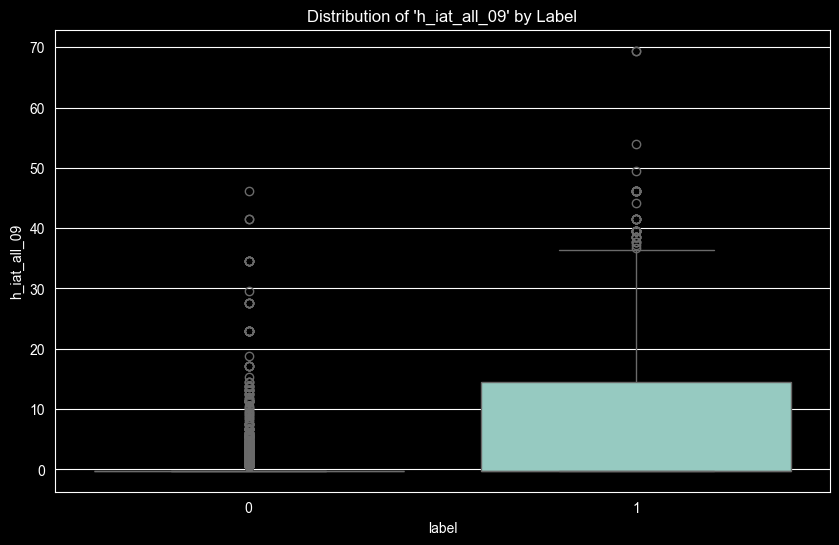

In [6]:
# 5. Distribution of Top Feature
top_feat = imp_df.iloc[0]["Feature"]
plt.figure(figsize=(10, 6))
sns.boxplot(x="label", y=top_feat, data=df_full)
plt.title(f"Distribution of '{top_feat}' by Label")
plt.show()
